# Double DQN
이 튜토리얼은 **Double DQN (Double Deep Q-Network)**을 구현하는 방법을 안내한다. Double DQN은 일반 DQN이 Q값을 과대평가(Overestimation)하는 문제를 해결하기 위해 제안된 알고리즘이다.

라이브러리는 최신 표준인 `gymnasium`과 `torch` 최신 버전을 기준으로 작성되었다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다. 코랩(Colab)이나 서버 환경에서는 화면이 없으므로 이를 통해 시각화를 가능하게 한다.

In [ ]:
# 최신 파이썬 라이브러리 설치 (gym 대신 gymnasium 사용)
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
# 화면이 없는 서버 환경에서 렌더링을 수행하기 위해 가상 윈도우를 생성한다.
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다. `pytorch_lightning` 의존성을 제거하고 순수 PyTorch로 구현한다.

In [2]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습된 에이전트의 플레이 영상을 주피터 노트북에서 확인할 수 있는 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Deep Q-Network 생성 (Create the Deep Q-Network)

상태를 입력받아 행동의 가치를 출력하는 신경망이다. Double DQN에서도 네트워크 구조 자체는 일반 DQN과 동일하다.

In [4]:
class DQN(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        """
        DQN 네트워크 초기화
        :param obs_size: 입력 상태의 차원
        :param hidden_size: 은닉층 노드 수
        :param n_actions: 출력 행동의 수
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x.float())

### 5. 경험 리플레이 버퍼 (Replay Buffer)

데이터의 상관관계를 끊고 학습 안정성을 높이기 위해 경험을 저장하는 버퍼다.

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

### 6. Pytorch Wrapper 클래스 (Double DQN 구현)

여기가 핵심이다. `train_step` 메서드에서 **Double DQN**의 타겟 계산 방식을 구현한다.

* **DQN**: 타겟 네트워크에서 최대 Q값을 선택 ()
* **Double DQN**: 메인 네트워크가 행동을 선택하고, 타겟 네트워크가 그 행동의 가치를 평가 ()

In [6]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=128, lr=1e-3, capacity=100000,
                 gamma=0.99, batch_size=256, sync_rate=10):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.sync_rate = sync_rate

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        n_actions = self.env.action_space.n

        # 네트워크 초기화
        self.q_net = DQN(obs_size, hidden_size, n_actions).to(device)
        self.target_q_net = copy.deepcopy(self.q_net).to(device)

        # 최적화기 및 손실함수
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

        # 리플레이 버퍼
        self.buffer = ReplayBuffer(capacity)

    def get_action(self, state, epsilon):
        if random.random() < epsilon:
            return self.env.action_space.sample()
        else:
            state_t = torch.tensor(np.array([state]), device=device)
            q_values = self.q_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), device=device)
        actions = torch.tensor(actions, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, device=device).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), device=device)

        # 1. 현재 상태의 Q값 계산 (Main Net)
        state_action_values = self.q_net(states).gather(1, actions)

        # 2. 타겟 Q값 계산 (Double DQN Logic)
        with torch.no_grad():
            # (A) 행동 선택: Main Net을 사용하여 다음 상태에서 가장 좋은 행동을 고른다.
            next_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)

            # (B) 가치 평가: Target Net을 사용하여 위에서 고른 행동의 가치를 계산한다.
            next_action_values = self.target_q_net(next_states).gather(1, next_actions)

            # 종료된 상태는 미래 보상이 0
            expected_state_action_values = rewards + (1 - dones) * self.gamma * next_action_values

        # 손실 계산 및 역전파
        loss = self.loss_fn(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def run_training(self, max_episodes=600, max_steps=400):
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0

            # 입실론 감쇠
            epsilon = max(0.01, 1.0 - (episode / 200))

            for step in range(max_steps):
                action = self.get_action(state, epsilon)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.buffer.append((state, action, reward, done, next_state))
                state = next_state
                episode_reward += reward

                self.train_step()

                if done:
                    break

            # 타겟 네트워크 동기화
            if episode % self.sync_rate == 0:
                self.target_q_net.load_state_dict(self.q_net.state_dict())

            total_rewards.append(episode_reward)

            if episode % 20 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {epsilon:.2f}")

        return total_rewards

    def save_video(self, filename="double_dqn_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False
        while not done:
            action = self.get_action(state, epsilon=0.0)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 7. 학습 실행 (Training)

Double DQN 에이전트를 생성하고 학습을 시작한다.

In [7]:
# Double DQN 모델 생성
agent = PytorchWrapper('LunarLander-v3', hidden_size=128, lr=1e-3)

# 학습 시작
print("Double DQN 학습을 시작한다...")
history = agent.run_training(max_episodes=600)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Double DQN 학습을 시작한다...
Episode 0, Reward: -314.17, Epsilon: 1.00
Episode 20, Reward: -181.22, Epsilon: 0.90
Episode 40, Reward: -172.63, Epsilon: 0.80
Episode 60, Reward: -160.64, Epsilon: 0.70
Episode 80, Reward: 23.61, Epsilon: 0.60
Episode 100, Reward: -11.79, Epsilon: 0.50
Episode 120, Reward: 22.56, Epsilon: 0.40
Episode 140, Reward: -52.11, Epsilon: 0.30
Episode 160, Reward: 42.56, Epsilon: 0.20
Episode 180, Reward: 1.69, Epsilon: 0.10
Episode 200, Reward: 12.96, Epsilon: 0.01
Episode 220, Reward: 40.73, Epsilon: 0.01
Episode 240, Reward: 16.91, Epsilon: 0.01
Episode 260, Reward: -93.10, Epsilon: 0.01
Episode 280, Reward: 102.20, Epsilon: 0.01
Episode 300, Reward: 50.91, Epsilon: 0.01
Episode 320, Reward: 80.94, Epsilon: 0.01
Episode 340, Reward: 80.64, Epsilon: 0.01
Episode 360, Reward: 122.07, Epsilon: 0.01
Episode 380, Reward: 69.17, Epsilon: 0.01
Episode 400, Reward: 69.84, Epsilon: 0.01
Episode 420, Reward: 108.51, Epsilon: 0.01
Episode 440, Reward: 126.38, Epsilon: 0.01
Epi

### 8. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

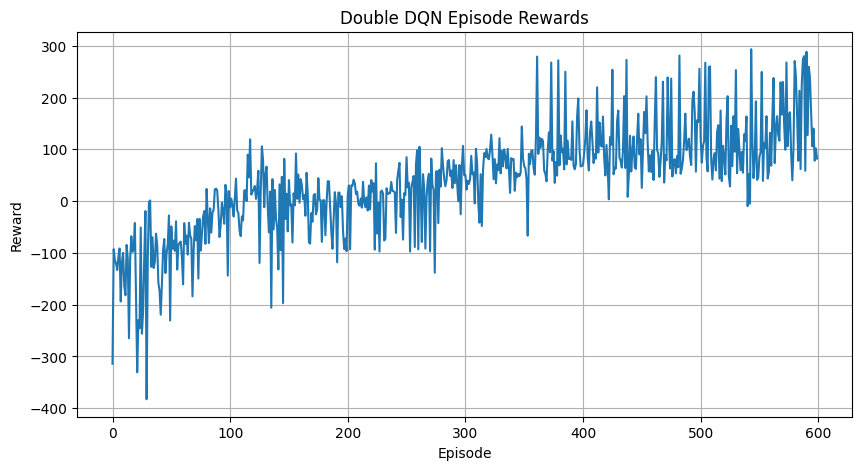

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [8]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("Double DQN Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("double-dqn")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")